<a href="https://colab.research.google.com/github/jpcampos04/2605_leaf_diseases_cv/blob/main/2605_leaf_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yusufmurtaza01/tomato-leaf-disease")

print("Path to dataset files:", path)

100%|██████████| 445M/445M [00:02<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2


In [5]:
train_images_dir = '/kaggle/input/datasets/yusufmurtaza01/tomato-leaf-disease/tomato/images/train'

In [6]:
all_train_imgs = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
sample_imgs = random.sample(all_train_imgs, 10)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/yusufmurtaza01/tomato-leaf-disease/tomato/images/train'

NameError: name 'sample_imgs' is not defined

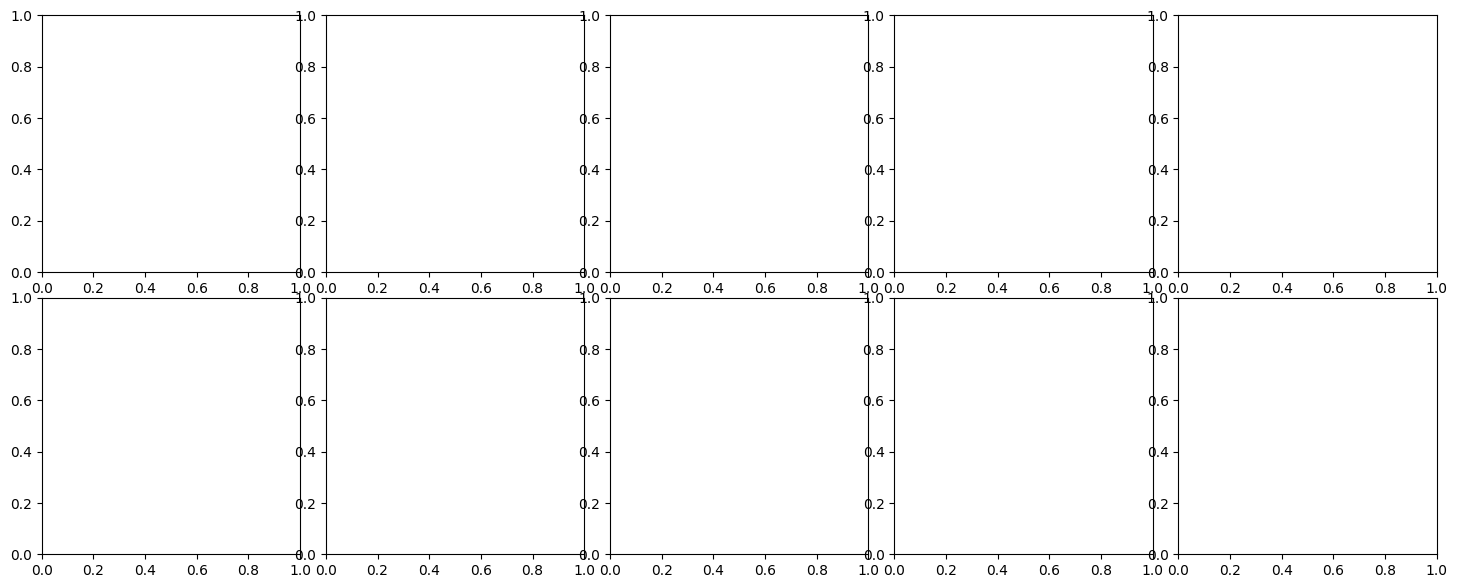

In [7]:
# 2. Plot with zero padding
fig, axes = plt.subplots(2, 5, figsize=(18, 7), facecolor='white')
fig.subplots_adjust(wspace=0.1, hspace=0.1)

padding_size = 2 # Adjust the thickness of the zero padding here

for i, ax in enumerate(axes.flatten()):
    img_path = os.path.join(train_images_dir, sample_imgs[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Explicitly add zero padding (black border) around the image
    padded_img = cv2.copyMakeBorder(
        img,
        padding_size, padding_size, padding_size, padding_size,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0] # Zero padding
    )

    ax.imshow(padded_img)
    ax.axis('off')
    ax.set_title(f"Image {i+1}", fontsize=10)

plt.show()

In [4]:
import os
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the correct one, or if there's only one.
    csv_file_path = os.path.join(path, csv_files[0])
    labels = pd.read_csv(csv_file_path)
    print(f"Successfully loaded {csv_files[0]}")
else:
    print(f"No CSV files found in the directory: {path}")
    labels = None


No CSV files found in the directory: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2


In [ ]:
import os

# Load Dataset
# The 'path' variable from kagglehub.dataset_download is a directory.
# We need to find the actual CSV file within this directory.

# Assuming the labels CSV file is named 'labels.csv' or similar inside the downloaded directory.
# Let's list the contents of the directory to confirm or find the correct file name.
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the correct one, or if there's only one.
    csv_file_path = os.path.join(path, csv_files[0])
    labels = pd.read_csv(csv_file_path)
    print(f"Successfully loaded {csv_files[0]}")
else:
    print(f"No CSV files found in the directory: {path}")
    labels = None


IsADirectoryError: [Errno 21] Is a directory: '/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2'